In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm
from statsmodels.formula.api import ols

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('../data/processed/cleaned_data.csv')

print("STATISTICAL ANALYSIS: STRESS AND EXAM PERFORMANCE")
print("="*70)
print(f"Sample size: {len(df):,} students")
print(f"Variables: {df.shape[1]}\n")

STATISTICAL ANALYSIS: STRESS AND EXAM PERFORMANCE
Sample size: 12,469 students
Variables: 22



In [2]:
print("ANALYSIS 1: ONE-WAY ANOVA")
print("="*70)

low_stress = df[df['StressLevel'] == 0]['ExamScore']
med_stress = df[df['StressLevel'] == 1]['ExamScore']
high_stress = df[df['StressLevel'] == 2]['ExamScore']

f_stat, p_value = stats.f_oneway(low_stress, med_stress, high_stress)

grand_mean = df['ExamScore'].mean()
ss_between = sum([len(low_stress) * (low_stress.mean() - grand_mean)**2, len(med_stress) * (med_stress.mean() - grand_mean)**2, len(high_stress) * (high_stress.mean() - grand_mean)**2])
ss_total = sum((df['ExamScore'] - grand_mean)**2)
eta_squared = ss_between / ss_total

print(f"\nF-statistic: {f_stat:.3f}")
print(f"p-value: {p_value:.6f}")
print(f"Effect size (eta-squared): {eta_squared:.4f}")

if eta_squared < 0.01:
    effect = "negligible"
elif eta_squared < 0.06:
    effect = "small"
elif eta_squared < 0.14:
    effect = "medium"
else:
    effect = "large"

print(f"Interpretation: {effect} effect\n")

summary = df.groupby('StressLevel')['ExamScore'].agg(['mean', 'std', 'count'])
summary.index = ['Low Stress', 'Medium Stress', 'High Stress']
print("Descriptive Statistics by Group:")
print(summary.round(2))

ANALYSIS 1: ONE-WAY ANOVA

F-statistic: 12.984
p-value: 0.000002
Effect size (eta-squared): 0.0021
Interpretation: negligible effect

Descriptive Statistics by Group:
                mean    std  count
Low Stress     71.90  17.51   2524
Medium Stress  69.74  17.83   3614
High Stress    70.00  17.66   6331


In [3]:
print("\nANALYSIS 2: POST-HOC PAIRWISE COMPARISONS")
print("="*70)

alpha = 0.05
n_comparisons = 3
bonferroni_alpha = alpha / n_comparisons

print(f"Bonferroni-corrected alpha: {bonferroni_alpha:.4f}\n")

comparisons = [('Low', 'Medium', low_stress, med_stress), ('Low', 'High', low_stress, high_stress), ('Medium', 'High', med_stress, high_stress)]

print(f"{'Comparison':<20} {'Mean Diff':<12} {'t-stat':<10} {'p-value':<12} {'Sig?'}")
print("-" * 75)

for name1, name2, group1, group2 in comparisons:
    t_stat, p_val = stats.ttest_ind(group1, group2)
    mean_diff = group1.mean() - group2.mean()
    is_sig = "Yes" if p_val < bonferroni_alpha else "No"
    print(f"{name1} vs {name2:<12} {mean_diff:>10.2f}   {t_stat:>8.3f}   {p_val:>10.6f}   {is_sig}")

print("\nEffect Sizes (Cohen's d):")
for name1, name2, g1, g2 in comparisons:
    t_stat, p_val = stats.ttest_ind(g1, g2)
    if p_val < bonferroni_alpha:
        pooled_std = np.sqrt(((len(g1)-1)*g1.std()**2 + (len(g2)-1)*g2.std()**2) / (len(g1)+len(g2)-2))
        cohens_d = (g1.mean() - g2.mean()) / pooled_std
        
        if abs(cohens_d) < 0.2:
            interp = "negligible"
        elif abs(cohens_d) < 0.5:
            interp = "small"
        elif abs(cohens_d) < 0.8:
            interp = "medium"
        else:
            interp = "large"
        
        print(f"  {name1} vs {name2}: d = {cohens_d:.3f} ({interp})")


ANALYSIS 2: POST-HOC PAIRWISE COMPARISONS
Bonferroni-corrected alpha: 0.0167

Comparison           Mean Diff    t-stat     p-value      Sig?
---------------------------------------------------------------------------
Low vs Medium             2.16      4.693     0.000003   Yes
Low vs High               1.89      4.565     0.000005   Yes
Medium vs High              -0.26     -0.708     0.478701   No

Effect Sizes (Cohen's d):
  Low vs Medium: d = 0.122 (negligible)
  Low vs High: d = 0.107 (negligible)


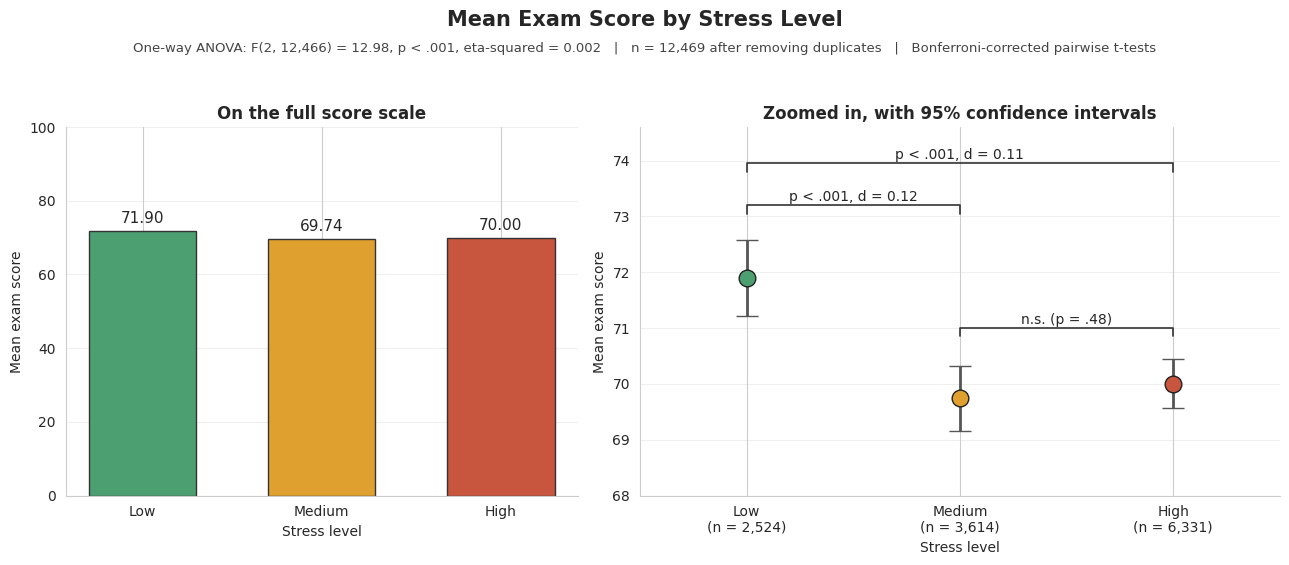

In [4]:
# Main-finding figure for the README (cleaned data)
labels = ['Low', 'Medium', 'High']
groups = [low_stress, med_stress, high_stress]
means = [g.mean() for g in groups]
ci95 = [1.96 * g.std() / np.sqrt(len(g)) for g in groups]
counts = [len(g) for g in groups]
colors = ['#4C9F70', '#E0A030', '#C8553D']
pvals = {(i, j): stats.ttest_ind(groups[i], groups[j])[1] for i, j in [(0, 1), (0, 2), (1, 2)]}
d_low_med = (low_stress.mean() - med_stress.mean()) / np.sqrt((low_stress.var() + med_stress.var()) / 2)
d_low_high = (low_stress.mean() - high_stress.mean()) / np.sqrt((low_stress.var() + high_stress.var()) / 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), gridspec_kw={'width_ratios': [1, 1.25]})

ax = axes[0]
ax.bar(labels, means, color=colors, edgecolor='#333', width=0.6)
ax.set_ylim(0, 100)
for i, m in enumerate(means):
    ax.text(i, m + 2, f'{m:.2f}', ha='center', fontsize=11)
ax.set_title('On the full score scale', fontsize=12, fontweight='bold')
ax.set_xlabel('Stress level')
ax.set_ylabel('Mean exam score')

ax = axes[1]
ax.errorbar(range(3), means, yerr=ci95, fmt='none', ecolor='#555', capsize=8, lw=2)
for i, c in enumerate(colors):
    ax.plot(i, means[i], 'o', color=c, markersize=12, mec='#222', zorder=3)
ax.set_xticks(range(3))
ax.set_xticklabels([f'{l}\n(n = {n:,})' for l, n in zip(labels, counts)])
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(68, 74.6)
ax.set_title('Zoomed in, with 95% confidence intervals', fontsize=12, fontweight='bold')
ax.set_xlabel('Stress level')
ax.set_ylabel('Mean exam score')

def bracket(x1, x2, y, text):
    ax.plot([x1, x1, x2, x2], [y - 0.15, y, y, y - 0.15], color='#333', lw=1.2)
    ax.text((x1 + x2) / 2, y + 0.08, text, ha='center', fontsize=10)

def ptext(p):
    return 'p < .001' if p < 0.001 else f'p = {p:.2f}'.replace('0.', '.')

bracket(0, 1, 73.2, f'{ptext(pvals[(0, 1)])}, d = {d_low_med:.2f}')
bracket(0, 2, 73.95, f'{ptext(pvals[(0, 2)])}, d = {d_low_high:.2f}')
bracket(1, 2, 71.0, f'n.s. ({ptext(pvals[(1, 2)])})')

for a in axes:
    a.grid(axis='y', alpha=0.3)
    a.spines[['top', 'right']].set_visible(False)

fig.suptitle('Mean Exam Score by Stress Level', fontsize=15, fontweight='bold', y=1.0)
fig.text(0.5, 0.925,
         f'One-way ANOVA: F(2, {len(df) - 3:,}) = {f_stat:.2f}, p < .001, eta-squared = {eta_squared:.3f}   |   '
         f'n = {len(df):,} after removing duplicates   |   Bonferroni-corrected pairwise t-tests',
         ha='center', fontsize=9.5, color='#444')
fig.tight_layout(rect=(0, 0, 1, 0.92))
plt.savefig('../figures/stress_performance_main_finding.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

In [5]:
print("\nANALYSIS 3: SIMPLE LINEAR REGRESSION")
print("="*70)

X_simple = df[['StressLevel']].values
y = df['ExamScore'].values

model_simple = LinearRegression()
model_simple.fit(X_simple, y)
y_pred_simple = model_simple.predict(X_simple)

r2_simple = r2_score(y, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y, y_pred_simple))
mae_simple = mean_absolute_error(y, y_pred_simple)

print("\nModel: ExamScore ~ StressLevel")
print(f"Intercept: {model_simple.intercept_:.3f}")
print(f"Coefficient: {model_simple.coef_[0]:.3f}")
print(f"\nR-squared: {r2_simple:.4f}")
print(f"RMSE: {rmse_simple:.3f}")
print(f"MAE: {mae_simple:.3f}")

X_sm = sm.add_constant(X_simple)
model_sm_simple = sm.OLS(y, X_sm).fit()
print(f"\nCoefficient p-value: {model_sm_simple.pvalues[1]:.6f}")


ANALYSIS 3: SIMPLE LINEAR REGRESSION

Model: ExamScore ~ StressLevel
Intercept: 71.320
Coefficient: -0.773

R-squared: 0.0012
RMSE: 17.686
MAE: 15.330

Coefficient p-value: 0.000126


In [6]:
print("\nANALYSIS 4: MULTIPLE REGRESSION")
print("="*70)

predictors = ['StressLevel']
for var in ['StudyHours', 'Attendance', 'Motivation', 'AssignmentCompletion']:
    if var in df.columns:
        predictors.append(var)

print(f"Predictors: {predictors}\n")

df_model = df[predictors + ['ExamScore']].dropna()
X_multiple = df_model[predictors].values
y_multiple = df_model['ExamScore'].values

print(f"Sample size: {len(df_model):,}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_multiple)

model_multiple = LinearRegression()
model_multiple.fit(X_scaled, y_multiple)
y_pred_multiple = model_multiple.predict(X_scaled)

r2_multiple = r2_score(y_multiple, y_pred_multiple)
rmse_multiple = np.sqrt(mean_squared_error(y_multiple, y_pred_multiple))
mae_multiple = mean_absolute_error(y_multiple, y_pred_multiple)

print(f"\nR-squared: {r2_multiple:.4f}")
print(f"RMSE: {rmse_multiple:.3f}")
print(f"MAE: {mae_multiple:.3f}")
print(f"\nImprovement over simple model:")
print(f"  Delta R-squared: {r2_multiple - r2_simple:.4f}")

print(f"\nCoefficients (change in exam points per 1 SD increase in predictor):")
print(f"{'Variable':<25} {'Coef':<10}")
print("-" * 40)
for i, var in enumerate(predictors):
    print(f"{var:<25} {model_multiple.coef_[i]:>8.3f}")

X_sm_mult = sm.add_constant(X_scaled)
model_sm_mult = sm.OLS(y_multiple, X_sm_mult).fit()

print(f"\nStatistical Significance:")
print(f"{'Variable':<25} {'p-value':<12} {'Sig?'}")
print("-" * 50)
for i, var in enumerate(predictors):
    p_val = model_sm_mult.pvalues[i+1]
    sig = "Yes" if p_val < 0.05 else "No"
    print(f"{var:<25} {p_val:>10.6f}   {sig}")


ANALYSIS 4: MULTIPLE REGRESSION
Predictors: ['StressLevel', 'StudyHours', 'Attendance', 'Motivation', 'AssignmentCompletion']

Sample size: 12,469

R-squared: 0.0022
RMSE: 17.676
MAE: 15.323

Improvement over simple model:
  Delta R-squared: 0.0010

Coefficients (change in exam points per 1 SD increase in predictor):
Variable                  Coef      
----------------------------------------
StressLevel                 -0.621
StudyHours                   0.081
Attendance                  -0.263
Motivation                  -0.068
AssignmentCompletion         0.494

Statistical Significance:
Variable                  p-value      Sig?
--------------------------------------------------
StressLevel                 0.000089   Yes
StudyHours                  0.611249   No
Attendance                  0.096615   No
Motivation                  0.666122   No
AssignmentCompletion        0.001804   Yes



ANALYSIS 5: MODERATION - Stress x Study Hours

Main effects only R-squared: 0.0012
With interaction R-squared: 0.0013
R-squared change: 0.0001

Interaction term:
  Coefficient: -0.0347
  p-value: 0.303426
  Significant: No


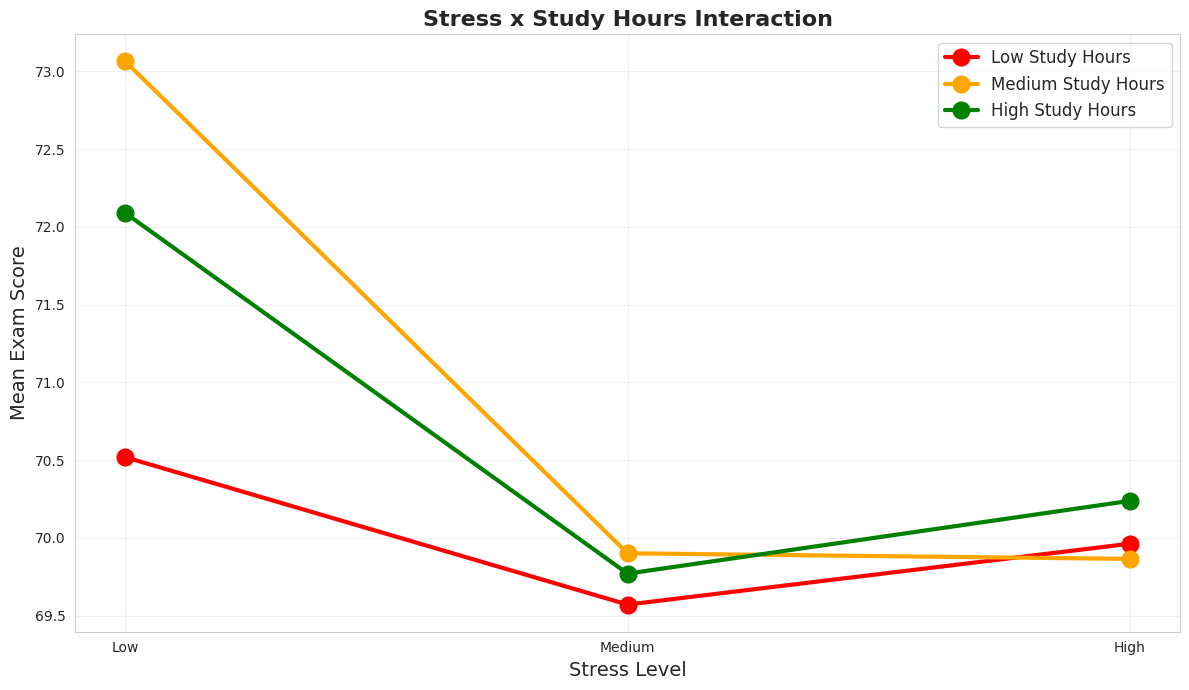

In [7]:
if 'StudyHours' in df.columns:
    print("\nANALYSIS 5: MODERATION - Stress x Study Hours")
    print("="*70)
    
    df_interact = df[['StressLevel', 'StudyHours', 'ExamScore']].dropna()
    
    df_interact['Stress_c'] = df_interact['StressLevel'] - df_interact['StressLevel'].mean()
    df_interact['Study_c'] = df_interact['StudyHours'] - df_interact['StudyHours'].mean()
    df_interact['Stress_x_Study'] = df_interact['Stress_c'] * df_interact['Study_c']
    
    model_main = ols('ExamScore ~ Stress_c + Study_c', data=df_interact).fit()
    model_interact = ols('ExamScore ~ Stress_c + Study_c + Stress_x_Study', data=df_interact).fit()
    
    print(f"\nMain effects only R-squared: {model_main.rsquared:.4f}")
    print(f"With interaction R-squared: {model_interact.rsquared:.4f}")
    print(f"R-squared change: {model_interact.rsquared - model_main.rsquared:.4f}")
    
    interact_coef = model_interact.params['Stress_x_Study']
    interact_pval = model_interact.pvalues['Stress_x_Study']
    
    print(f"\nInteraction term:")
    print(f"  Coefficient: {interact_coef:.4f}")
    print(f"  p-value: {interact_pval:.6f}")
    print(f"  Significant: {'Yes' if interact_pval < 0.05 else 'No'}")
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    study_tertiles = df_interact['StudyHours'].quantile([0.33, 0.67])
    
    low_study = df_interact[df_interact['StudyHours'] <= study_tertiles.iloc[0]]
    med_study = df_interact[(df_interact['StudyHours'] > study_tertiles.iloc[0]) & (df_interact['StudyHours'] <= study_tertiles.iloc[1])]
    high_study = df_interact[df_interact['StudyHours'] > study_tertiles.iloc[1]]
    
    for data, label, color in [(low_study, 'Low Study Hours', 'red'), (med_study, 'Medium Study Hours', 'orange'), (high_study, 'High Study Hours', 'green')]:
        means = data.groupby('StressLevel')['ExamScore'].mean()
        ax.plot([0, 1, 2], means, marker='o', linewidth=3, markersize=12, label=label, color=color)
    
    ax.set_title('Stress x Study Hours Interaction', fontsize=16, fontweight='bold')
    ax.set_xlabel('Stress Level', fontsize=14)
    ax.set_ylabel('Mean Exam Score', fontsize=14)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Low', 'Medium', 'High'])
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../figures/moderation_stress_study.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\nStudyHours not available for moderation analysis")


ANALYSIS 6: REGRESSION DIAGNOSTICS


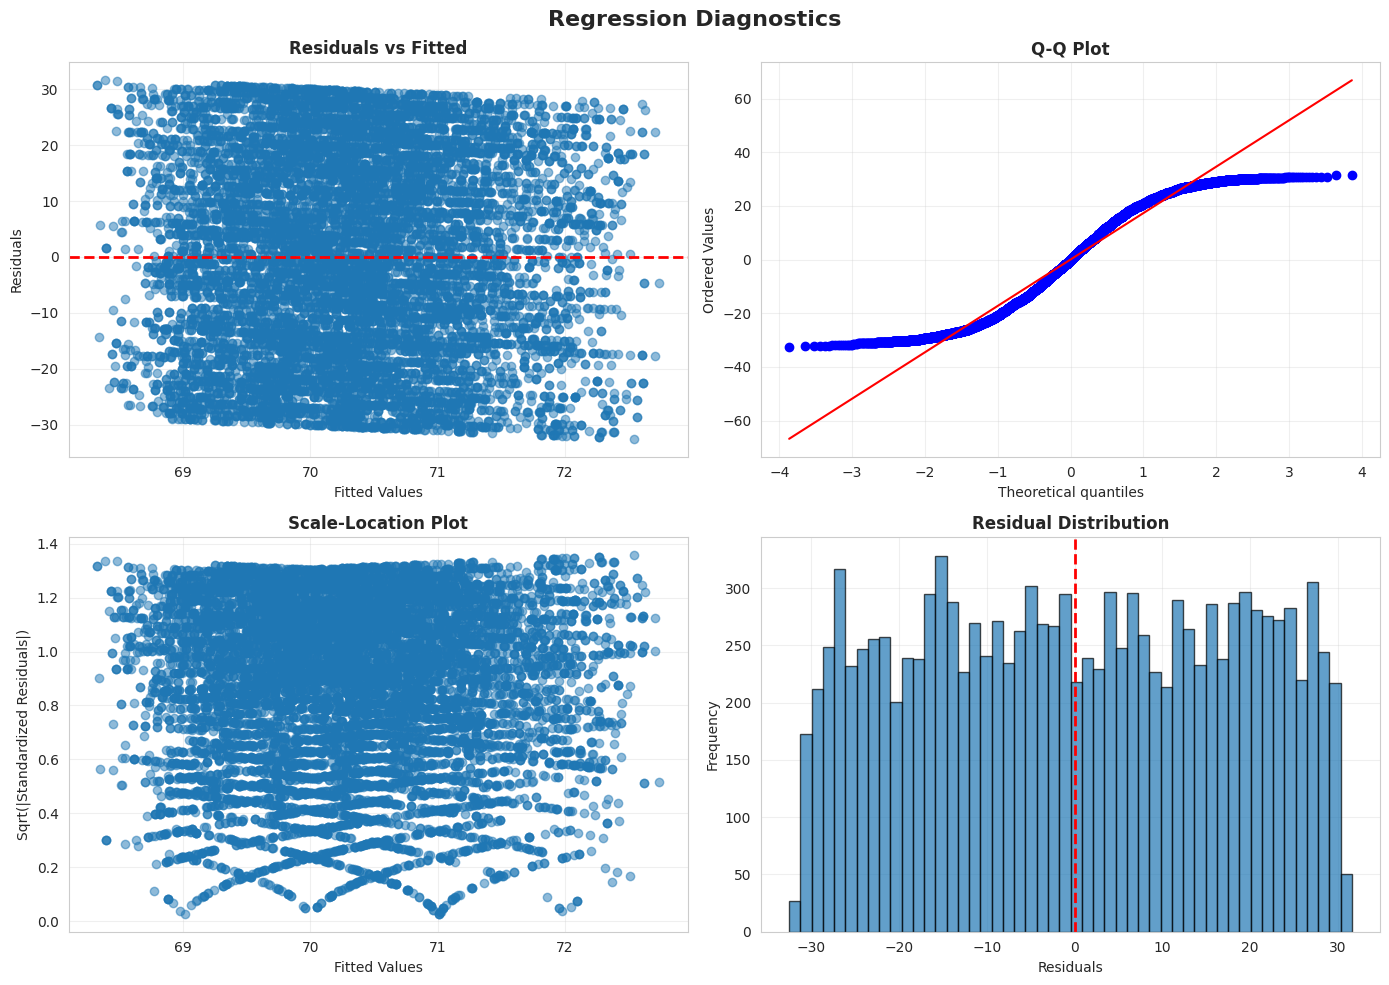


Shapiro-Wilk test (sample of 5000):
  W-statistic: 0.9570
  p-value: 0.000000
  Normality assumption: Violated


In [8]:
print("\nANALYSIS 6: REGRESSION DIAGNOSTICS")
print("="*70)

if 'model_sm_mult' in locals():
    residuals = model_sm_mult.resid
    fitted_values = model_sm_mult.fittedvalues
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    axes[0, 0].scatter(fitted_values, residuals, alpha=0.5)
    axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[0, 0].set_xlabel('Fitted Values')
    axes[0, 0].set_ylabel('Residuals')
    axes[0, 0].set_title('Residuals vs Fitted', fontweight='bold')
    axes[0, 0].grid(alpha=0.3)
    
    stats.probplot(residuals, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title('Q-Q Plot', fontweight='bold')
    axes[0, 1].grid(alpha=0.3)
    
    standardized_resid = (residuals - residuals.mean()) / residuals.std()
    axes[1, 0].scatter(fitted_values, np.sqrt(np.abs(standardized_resid)), alpha=0.5)
    axes[1, 0].set_xlabel('Fitted Values')
    axes[1, 0].set_ylabel('Sqrt(|Standardized Residuals|)')
    axes[1, 0].set_title('Scale-Location Plot', fontweight='bold')
    axes[1, 0].grid(alpha=0.3)
    
    axes[1, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
    axes[1, 1].set_xlabel('Residuals')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Residual Distribution', fontweight='bold')
    axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[1, 1].grid(alpha=0.3)
    
    plt.suptitle('Regression Diagnostics', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../figures/regression_diagnostics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    if len(residuals) > 5000:
        rng = np.random.default_rng(42)
        sample_resid = rng.choice(residuals, 5000, replace=False)
        shapiro_stat, shapiro_p = stats.shapiro(sample_resid)
        print(f"\nShapiro-Wilk test (sample of 5000):")
    else:
        shapiro_stat, shapiro_p = stats.shapiro(residuals)
        print(f"\nShapiro-Wilk test:")
    
    print(f"  W-statistic: {shapiro_stat:.4f}")
    print(f"  p-value: {shapiro_p:.6f}")
    print(f"  Normality assumption: {'Satisfied' if shapiro_p > 0.05 else 'Violated'}")


MODEL COMPARISON

              Model                                                            Predictors       R²      RMSE
  Simple Regression                                                           Stress only 0.001178 17.685502
Multiple Regression StressLevel, StudyHours, Attendance, Motivation, AssignmentCompletion 0.002213 17.676339
   With Interaction                                          Stress + Study + Interaction 0.001282 17.684580


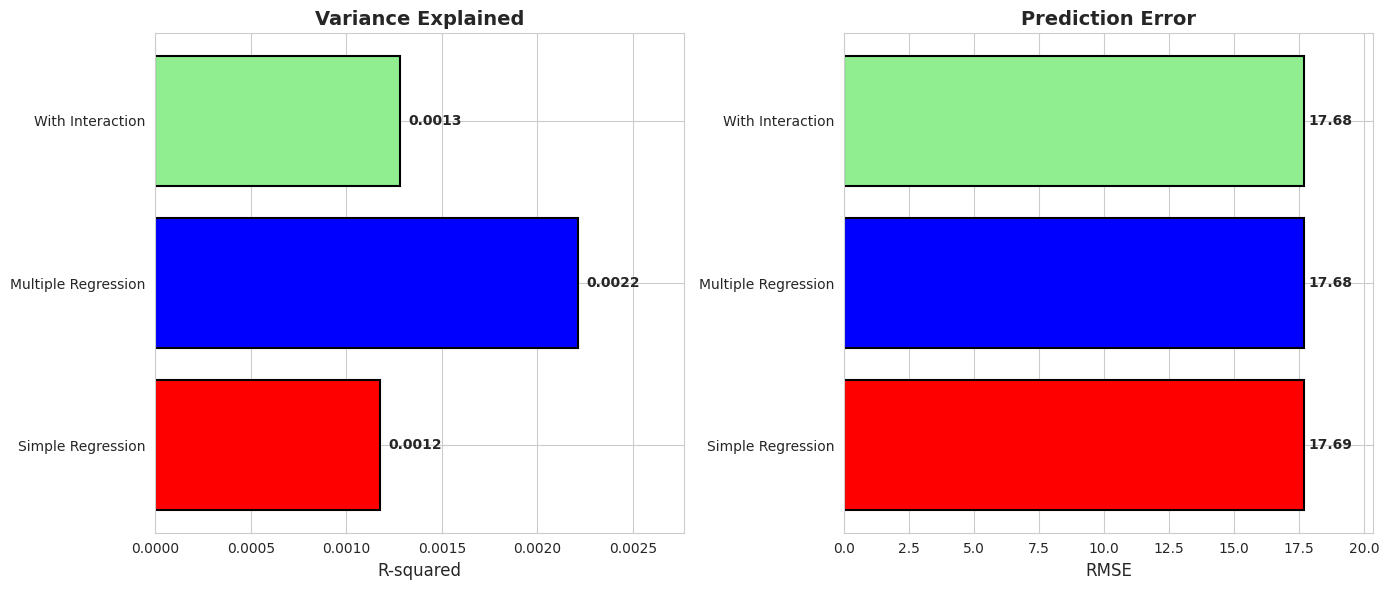


Best model (highest R-squared): Multiple Regression


In [9]:
print("\nMODEL COMPARISON")
print("="*70)

models_summary = []

if 'r2_simple' in locals():
    models_summary.append({'Model': 'Simple Regression', 'Predictors': 'Stress only', 'R²': r2_simple, 'RMSE': rmse_simple})

if 'r2_multiple' in locals():
    models_summary.append({'Model': 'Multiple Regression', 'Predictors': ', '.join(predictors), 'R²': r2_multiple, 'RMSE': rmse_multiple})

if 'StudyHours' in df.columns and 'model_interact' in locals():
    models_summary.append({'Model': 'With Interaction', 'Predictors': 'Stress + Study + Interaction', 'R²': model_interact.rsquared, 'RMSE': np.sqrt(mean_squared_error(df_interact['ExamScore'], model_interact.fittedvalues))})

if len(models_summary) > 0:
    comparison_df = pd.DataFrame(models_summary)
    print("\n" + comparison_df.to_string(index=False))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    models = [m['Model'] for m in models_summary]
    r2_values = [m['R²'] for m in models_summary]
    rmse_values = [m['RMSE'] for m in models_summary]
    
    axes[0].barh(models, r2_values, color=['red', 'blue', 'lightgreen'][:len(models)], edgecolor='black', linewidth=1.5)
    axes[0].set_xlabel('R-squared', fontsize=12)
    axes[0].set_title('Variance Explained', fontsize=14, fontweight='bold')
    axes[0].set_xlim(0, max(r2_values) * 1.25)
    
    for i, (model, r2) in enumerate(zip(models, r2_values)):
        axes[0].text(r2 + max(r2_values) * 0.02, i, f'{r2:.4f}', va='center', fontweight='bold')
    
    axes[1].barh(models, rmse_values, color=['red', 'blue', 'lightgreen'][:len(models)], edgecolor='black', linewidth=1.5)
    axes[1].set_xlabel('RMSE', fontsize=12)
    axes[1].set_title('Prediction Error', fontsize=14, fontweight='bold')
    axes[1].set_xlim(0, max(rmse_values) * 1.15)
    
    for i, (model, rmse) in enumerate(zip(models, rmse_values)):
        axes[1].text(rmse + max(rmse_values) * 0.01, i, f'{rmse:.2f}', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../figures/model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nBest model (highest R-squared): {models[np.argmax(r2_values)]}")

In [10]:
print("\nSTATISTICAL ANALYSIS SUMMARY")
print("="*70)

print("\n1. MAIN EFFECT")
print(f"ANOVA: F = {f_stat:.2f}, p < 0.001, eta-squared = {eta_squared:.4f}")
print(f"Effect size: {effect}")
print(f"Low stress: M = {low_stress.mean():.2f}")
print(f"Medium stress: M = {med_stress.mean():.2f}")
print(f"High stress: M = {high_stress.mean():.2f}")

print("\n2. MULTIPLE REGRESSION")
print(f"R-squared: {r2_multiple:.4f}")
print(f"Variance explained: {r2_multiple*100:.1f}%")
print("Significant predictors (p < 0.05):")
for i, var in enumerate(predictors):
    p_val = model_sm_mult.pvalues[i+1]
    if p_val < 0.05:
        coef = model_multiple.coef_[i]
        print(f"{var}: {coef:+.3f} points per SD")

if 'StudyHours' in df.columns and 'model_interact' in locals():
    print("\n3. MODERATION")
    print(f"Interaction p-value: {interact_pval:.4f}")
    print(f"Significant: {'Yes' if interact_pval < 0.05 else 'No'}")

print("\n4. MODEL FIT")
print(f"Best R-squared: {max(r2_values):.4f}")
print(f"Best RMSE: {min(rmse_values):.2f}")

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)


STATISTICAL ANALYSIS SUMMARY

1. MAIN EFFECT
ANOVA: F = 12.98, p < 0.001, eta-squared = 0.0021
Effect size: negligible
Low stress: M = 71.90
Medium stress: M = 69.74
High stress: M = 70.00

2. MULTIPLE REGRESSION
R-squared: 0.0022
Variance explained: 0.2%
Significant predictors (p < 0.05):
StressLevel: -0.621 points per SD
AssignmentCompletion: +0.494 points per SD

3. MODERATION
Interaction p-value: 0.3034
Significant: No

4. MODEL FIT
Best R-squared: 0.0022
Best RMSE: 17.68

ANALYSIS COMPLETE
